### Тема: Вероятностный анализ распределения количества выигрышей в серии независимых испытаний на примере европейской рулетки.

Аннотация: Данная работа посвящена исследованию распределения частоты выигрышей в азартных играх с фиксированной вероятностью успеха на примере серии из 100 вращений колеса европейской рулетки.  

В качестве основного метода моделирования использована непрерывная аппроксимация биномиального распределения с помощью функции нормального распределения со средним значением mu ≈ 2.70 и стандартным отклонением sigma ≈ 1.62,  p = 1/37. Реализован численный подход к расчету вероятностей: разность функций распределения (CDF). Теоретически вероятность выпадения от 2 до 4 выигрышей за 100 игр составляет 63.70%. Разработанный программный алгоритм визуализирует плотность распределения. 

--- Результаты вычисления интеграла от 1.5 до 4.5 ---
1. Через CDF (разность вероятностей): 63.70


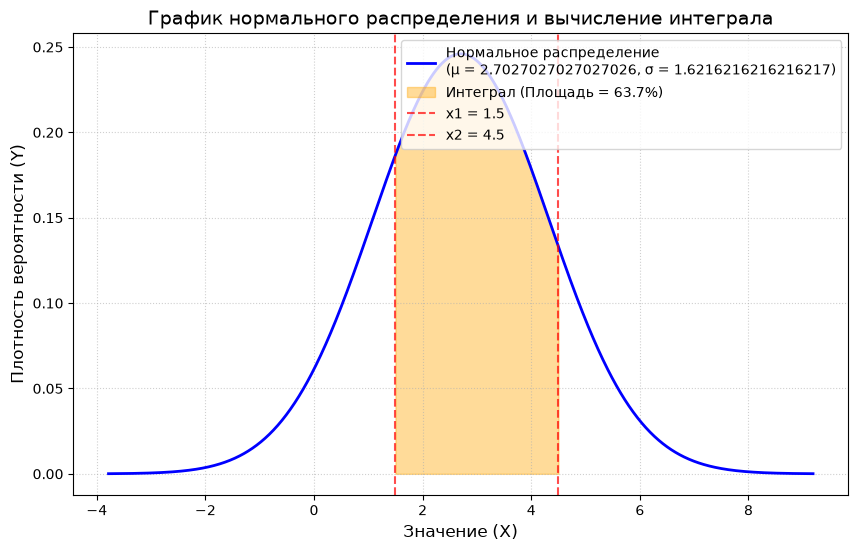

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.stats import norm
n = 100
p = 1/37
q = 36/37

mu = n * p  # Матожидание 
sigma = np.sqrt(n * p * q)  # Cтандартное отклонение


# Границы интегрирования (интервал, для которого ищем площадь)
x_start = 1.5
x_end = 4.5

# 2. ВЫЧИСЛЕНИЕ ИНТЕГРАЛА 

# Через функцию распределения CDF
# Интеграл от a до b равен: CDF(b) - CDF(a)
integral_cdf = norm.cdf(x_end, loc=mu, scale=sigma) - norm.cdf(
    x_start, loc=mu, scale=sigma
)

print(f"--- Результаты вычисления интеграла от {x_start} до {x_end} ---")
print(
    f"1. Через CDF (разность вероятностей): {integral_cdf * 100:.2f}"
)  

# 3. ПОСТРОЕНИЕ ГРАФИКА

# Генерируем точки для плавной кривой (от -4 до +4 стандартных отклонений)
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = norm.pdf(x, loc=mu, scale=sigma)  # Значения плотности распределения

plt.figure(figsize=(10, 6))

# Рисуем основную кривую распределения
plt.plot(
    x,
    y,
    label=f"Нормальное распределение\n(μ = {mu}, σ = {sigma})",
    color="blue",
    linewidth=2,
)

# Закрашиваем область под кривой, соответствующую интегралу
x_fill = np.linspace(x_start, x_end, 500)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(
    x_fill,
    y_fill,
    color="orange",
    alpha=0.4,
    label=f"Интеграл (Площадь = {integral_cdf:.1%})",
)

# Вертикальные линии границ интегрирования
plt.axvline(
    x_start, color="red", linestyle="--", alpha=0.7, label=f"x1 = {x_start}"
)
plt.axvline(
    x_end, color="red", linestyle="--", alpha=0.7, label=f"x2 = {x_end}"
)

# Оформление графика
plt.title(
    "График нормального распределения и вычисление интеграла", fontsize=14
)
plt.xlabel("Значение (X)", fontsize=12)
plt.ylabel("Плотность вероятности (Y)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", fontsize=10)

# Показываем график
plt.show()


Проверим с помощью функции np.random.binomial среднее количесво выигрышей. Где n - это количество испытаний за раз. p - вероятность. size сколько раз повторяем n испытаний. 
Функция возвращаяет массив [3, 2, 2, 3, 1...] где каждое число это количество успеха в n испытаниях.   

In [8]:
trials = np.random.binomial(n=100, p=1/37, size=100)
trials.mean()

np.float64(2.33)

In [9]:
# потенциальный средний выигрыш для ставки в 10, бюджет 1000, 
# наиболее вероятный выигрыш 2, проигрыш 98 составит:
# коэффицент умножения ставки 35
1000 + (10 * 35 * 2) - (10 * 98)

720

В качестве дополнительного предворительного анализа возьмем другую крайность, где p = 18/37.
mu ≈ 48.64. sigma ≈ 4.99


--- Результаты вычисления интеграла от 45.5 до 55.5 ---
1. Через CDF (разность вероятностей): 65.04


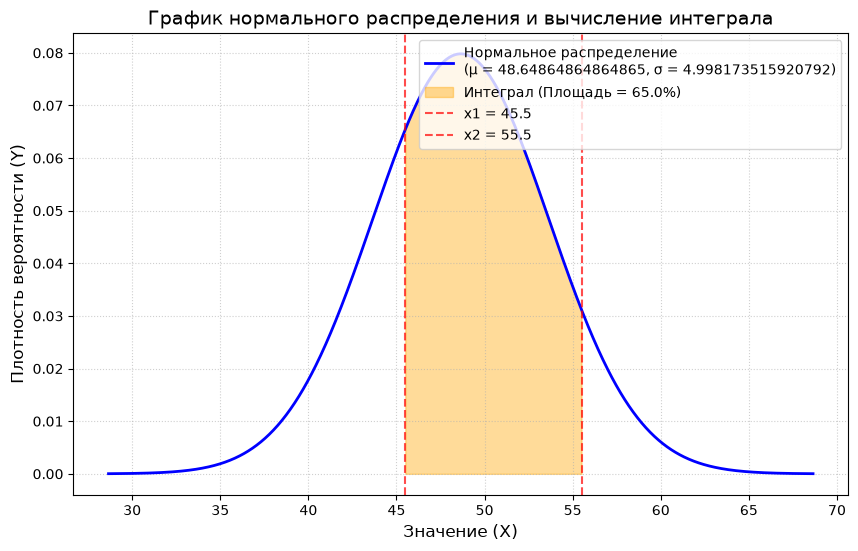

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.stats import norm
n = 100
p = 18/37
q = 19/37

mu = n * p  # Матожидание 
sigma = np.sqrt(n * p * q)  # Cтандартное отклонение

# Границы интегрирования (интервал, для которого ищем площадь)
x_start = 45.5
x_end = 55.5

# 2. ВЫЧИСЛЕНИЕ ИНТЕГРАЛА 

#Через функцию распределения CDF
# Интеграл от a до b равен: CDF(b) - CDF(a)
integral_cdf = norm.cdf(x_end, loc=mu, scale=sigma) - norm.cdf(
    x_start, loc=mu, scale=sigma
)

print(f"--- Результаты вычисления интеграла от {x_start} до {x_end} ---")
print(
    f"1. Через CDF (разность вероятностей): {integral_cdf * 100:.2f}"
)  

# 3. ПОСТРОЕНИЕ ГРАФИКА

# Генерируем точки для плавной кривой (от -4 до +4 стандартных отклонений)
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 1000)
y = norm.pdf(x, loc=mu, scale=sigma)  # Значения плотности распределения

plt.figure(figsize=(10, 6))

# Рисуем основную кривую распределения
plt.plot(
    x,
    y,
    label=f"Нормальное распределение\n(μ = {mu}, σ = {sigma})",
    color="blue",
    linewidth=2,
)

# Закрашиваем область под кривой, соответствующую интегралу
x_fill = np.linspace(x_start, x_end, 500)
y_fill = norm.pdf(x_fill, loc=mu, scale=sigma)
plt.fill_between(
    x_fill,
    y_fill,
    color="orange",
    alpha=0.4,
    label=f"Интеграл (Площадь = {integral_cdf:.1%})",
)

# Вертикальные линии границ интегрирования
plt.axvline(
    x_start, color="red", linestyle="--", alpha=0.7, label=f"x1 = {x_start}"
)
plt.axvline(
    x_end, color="red", linestyle="--", alpha=0.7, label=f"x2 = {x_end}"
)

# Оформление графика
plt.title(
    "График нормального распределения и вычисление интеграла", fontsize=14
)
plt.xlabel("Значение (X)", fontsize=12)
plt.ylabel("Плотность вероятности (Y)", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="upper right", fontsize=10)

# Показываем график
plt.show()


Проверим с помощью функции np.random.binomial среднее количесво выигрышей. 

In [11]:
trials = np.random.binomial(n=100, p=18/37, size=100)
trials.mean()

np.float64(48.7)

In [12]:
# потенциальный средний выигрыш для ставки в 10, бюджет 1000, 
# наиболее вероятный выигрыш 48, проигрыш 52 составит:
# коэффицент умножения ставки 1
1000 + (10 * 1 * 48) - (10 * 52)

960

В дальнейшем для более точного анализа и прогноза будет использован метод Монте - Карло. Симуляция в файле monte_carlo_sim.